# Exercício B - Funções
Funções para calcular potência inteira e multiplicar matrizes quadradas de mesma ordem.

In [1]:
def potencia_inteira(a: int, b: int) -> int:
    """Calcula a^b para b >= 0 usando multiplicação repetida."""
    if b < 0:
        raise ValueError("O expoente b deve ser inteiro não negativo.")

    resultado = 1
    for _ in range(b):
        resultado *= a
    return resultado


def multiplicar_matrizes_quadradas(matriz_a: list[list[float]], matriz_b: list[list[float]]) -> list[list[float]]:
    """Multiplica duas matrizes quadradas n x n."""
    if not matriz_a or not matriz_b:
        raise ValueError("As matrizes não podem ser vazias.")

    n = len(matriz_a)
    if len(matriz_b) != n:
        raise ValueError("As matrizes devem ter a mesma ordem n x n.")

    if any(len(linha) != n for linha in matriz_a) or any(len(linha) != n for linha in matriz_b):
        raise ValueError("As duas matrizes devem ser quadradas (n x n).")

    resultado = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            soma = 0
            for k in range(n):
                soma += matriz_a[i][k] * matriz_b[k][j]
            resultado[i][j] = soma

    return resultado


# Exemplos rápidos de uso
print("2^10 =", potencia_inteira(2, 10))

A = [
    [1, 2],
    [3, 4],
]
B = [
    [5, 6],
    [7, 8],
]

print("A x B =", multiplicar_matrizes_quadradas(A, B))

2^10 = 1024
A x B = [[19, 22], [43, 50]]


## Análise de tempo de execução
Nesta etapa medimos o tempo das funções para diferentes entradas e observamos o crescimento do custo computacional.

In [2]:
from time import perf_counter
import random


def medir_tempo_potencia(a: int, valores_b: list[int], repeticoes: int = 5) -> list[tuple[int, float]]:
    resultados = []

    for b in valores_b:
        tempos = []
        for _ in range(repeticoes):
            inicio = perf_counter()
            potencia_inteira(a, b)
            fim = perf_counter()
            tempos.append(fim - inicio)

        tempo_medio = sum(tempos) / repeticoes
        resultados.append((b, tempo_medio))

    return resultados


def gerar_matriz_quadrada(n: int, minimo: int = 0, maximo: int = 9) -> list[list[int]]:
    return [[random.randint(minimo, maximo) for _ in range(n)] for _ in range(n)]


def medir_tempo_multiplicacao(valores_n: list[int], repeticoes: int = 3) -> list[tuple[int, float]]:
    resultados = []

    for n in valores_n:
        tempos = []
        for _ in range(repeticoes):
            matriz_a = gerar_matriz_quadrada(n)
            matriz_b = gerar_matriz_quadrada(n)

            inicio = perf_counter()
            multiplicar_matrizes_quadradas(matriz_a, matriz_b)
            fim = perf_counter()
            tempos.append(fim - inicio)

        tempo_medio = sum(tempos) / repeticoes
        resultados.append((n, tempo_medio))

    return resultados


# Experimento 1: potência a^b (a fixo, variando b)
valores_b = [1_000, 5_000, 10_000, 20_000, 40_000]
resultado_potencia = medir_tempo_potencia(a=2, valores_b=valores_b, repeticoes=5)

print("Tempo da função potencia_inteira (esperado: O(b))")
for b, tempo in resultado_potencia:
    print(f"b={b:>6} -> {tempo:.8f} s")

print()

# Experimento 2: multiplicação de matrizes n x n
valores_n = [10, 20, 30, 40, 50]
resultado_matriz = medir_tempo_multiplicacao(valores_n=valores_n, repeticoes=3)

print("Tempo da multiplicação de matrizes (esperado: O(n^3))")
for n, tempo in resultado_matriz:
    print(f"n={n:>3} -> {tempo:.8f} s")

Tempo da função potencia_inteira (esperado: O(b))
b=  1000 -> 0.00005861 s
b=  5000 -> 0.00115647 s
b= 10000 -> 0.00356261 s
b= 20000 -> 0.01311685 s
b= 40000 -> 0.05154247 s

Tempo da multiplicação de matrizes (esperado: O(n^3))
n= 10 -> 0.00005782 s
n= 20 -> 0.00040543 s
n= 30 -> 0.00135589 s
n= 40 -> 0.00319367 s
n= 50 -> 0.00611463 s


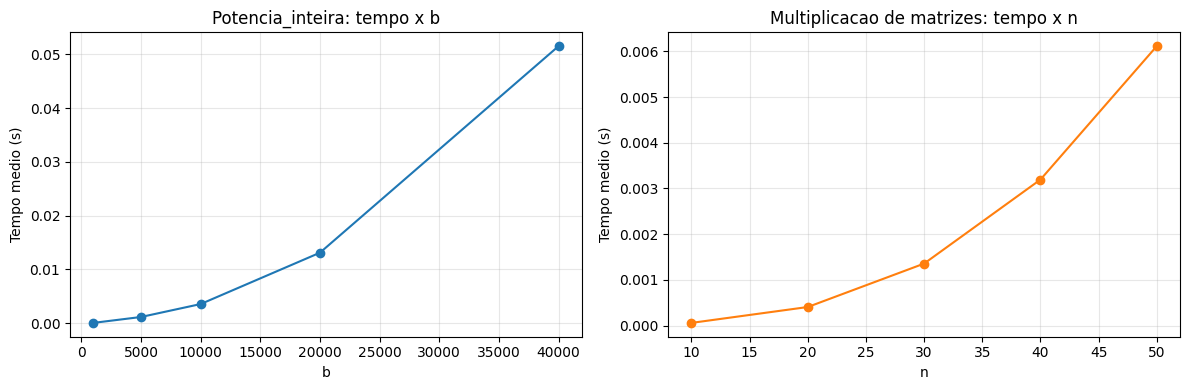

In [3]:
import sys
import subprocess

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib nao encontrado no kernel atual. Instalando...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

b_vals = [b for b, _ in resultado_potencia]
t_pot = [t for _, t in resultado_potencia]

n_vals = [n for n, _ in resultado_matriz]
t_mat = [t for _, t in resultado_matriz]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(b_vals, t_pot, marker="o", color="tab:blue")
axes[0].set_title("Potencia_inteira: tempo x b")
axes[0].set_xlabel("b")
axes[0].set_ylabel("Tempo medio (s)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_vals, t_mat, marker="o", color="tab:orange")
axes[1].set_title("Multiplicacao de matrizes: tempo x n")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Tempo medio (s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusão automática
A célula abaixo gera um texto final com base nos dados do experimento.

In [4]:
def fator_crescimento(resultados: list[tuple[int, float]]) -> float:
    x0, t0 = resultados[0]
    x1, t1 = resultados[-1]
    if t0 == 0:
        return float("inf")
    return t1 / t0


crescimento_pot = fator_crescimento(resultado_potencia)
crescimento_mat = fator_crescimento(resultado_matriz)

texto_conclusao = f"""
Conclusao do experimento:
1) Para a potencia a^b, o tempo aumentou aproximadamente {crescimento_pot:.2f}x do menor para o maior valor de b.
Isso e compativel com crescimento linear em funcao de b, ou seja, complexidade O(b).

2) Para a multiplicacao de matrizes n x n, o tempo aumentou aproximadamente {crescimento_mat:.2f}x do menor para o maior valor de n.
Esse comportamento e consistente com complexidade cubica O(n^3), causada pelos tres lacos aninhados.
""".strip()

print(texto_conclusao)

Conclusao do experimento:
1) Para a potencia a^b, o tempo aumentou aproximadamente 879.44x do menor para o maior valor de b.
Isso e compativel com crescimento linear em funcao de b, ou seja, complexidade O(b).

2) Para a multiplicacao de matrizes n x n, o tempo aumentou aproximadamente 105.75x do menor para o maior valor de n.
Esse comportamento e consistente com complexidade cubica O(n^3), causada pelos tres lacos aninhados.
